In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from da_models.sturis import rhs as rhs_sturis

In [2]:
ic_sturis = np.load("../data/sturis_ic.npy")
print(ic_sturis)

[   49.36583793   116.77968236 10631.64949338    49.36600702
    49.36611248    49.36612651]


**Simulation**

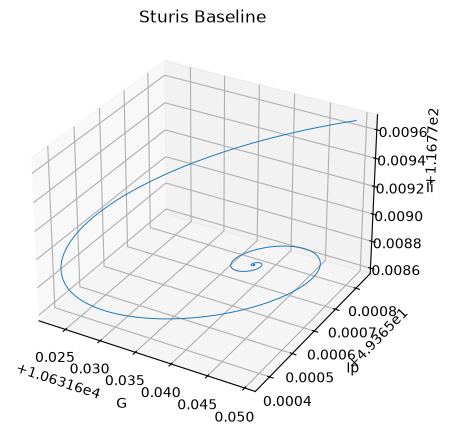

In [3]:
t_span = (0, 1000)
t_eval = np.linspace(*t_span, 1000)

sol_sturis = solve_ivp(rhs_sturis, t_span, ic_sturis, t_eval=t_eval, rtol=1e-9, atol=1e-9)

G = sol_sturis.y[2]
Ip = sol_sturis.y[0]
Ii = sol_sturis.y[1]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(G, Ip, Ii, lw=0.7)
ax.set_xlabel('G'); ax.set_ylabel('Ip'); ax.set_zlabel('Ii')
ax.set_title('Sturis Baseline')
plt.show()

**Perturbation**

In [4]:
sturis_params = dict(Vp=3.0, Vi=11.0, Vg=10.0, E=0.2, tp=6.0, ti=100.0, td=12.0,
                      Rm=209.0, a1=6.6, C1=300.0, C2=144.0, C3=100.0, C4=80.0, C5=26.0,
                      Ub=72.0, U0=4.0, Um=94.0, Rg=180.0, alpha=7.5, beta=1.772, IG=0.0)

params_tweak = {**sturis_params, 'td': 24.0}

sol_sturis_tweak = solve_ivp(
    lambda t, y: rhs_sturis(t, y, **params_tweak),
    t_span, ic_sturis, t_eval=t_eval, rtol=1e-9, atol=1e-9,
)

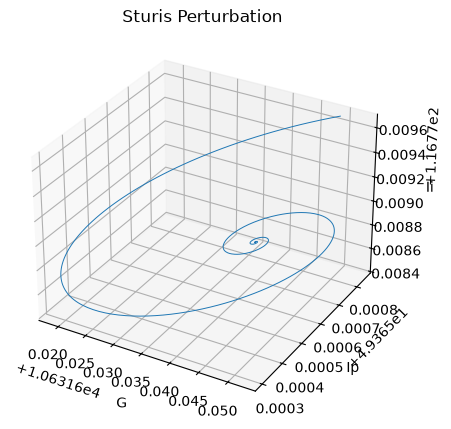

In [5]:
G_tweak = sol_sturis_tweak.y[2]
Ip_tweak = sol_sturis_tweak.y[0]
Ii_tweak = sol_sturis_tweak.y[1]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(G_tweak, Ip_tweak, Ii_tweak, lw=0.7)
ax.set_xlabel('G'); ax.set_ylabel('Ip'); ax.set_zlabel('Ii')
ax.set_title(f'Sturis Perturbation')
plt.show()

**Observations**

Doubling $t_{d}$ doesn't change the qualitative behavior, but it does appear to affect where the dyanmics converge to.